In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "/Users/tsantaloic/Desktop/Projet_05_AIA02/data/processed/amazon_reviews_cleaned.csv",
    parse_dates=["timestamp"]
)

df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


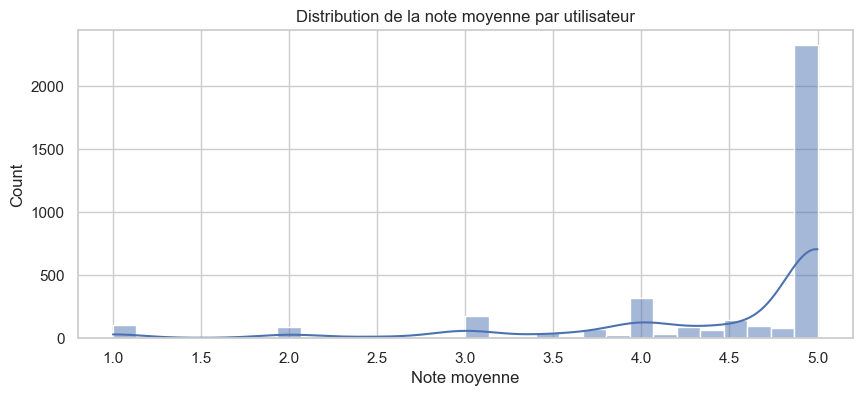

,user_id,avg_rating,rating_std,nb_reviews
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,5.000000,NaN,1
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,5.000000,NaN,1
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,5.000000,0.000000,2
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,4.555556,1.333333,9
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,4.333333,0.577350,3


In [3]:
# Note moyenne par utilisateur
user_rating_stats = df.groupby("user_id").agg(
    avg_rating=("rating", "mean"),
    rating_std=("rating", "std"),
    nb_reviews=("rating", "count")
).reset_index()



plt.figure(figsize=(10,4))
sns.histplot(user_rating_stats["avg_rating"], bins=30, kde=True)
plt.title("Distribution de la note moyenne par utilisateur")
plt.xlabel("Note moyenne")
plt.show()

user_rating_stats.head()



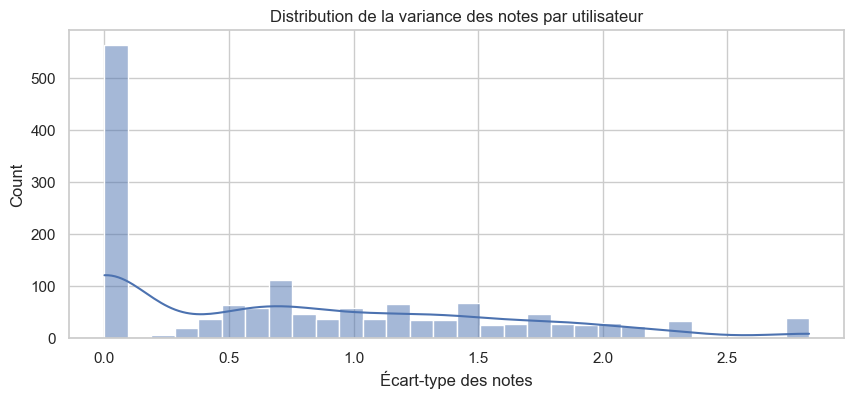

In [4]:
# Variance des notes (cohérence du jugement)
plt.figure(figsize=(10,4))
sns.histplot(user_rating_stats["rating_std"].dropna(), bins=30, kde=True)
plt.title("Distribution de la variance des notes par utilisateur")
plt.xlabel("Écart-type des notes")
plt.show()

# faible variance = jugement stable
# forte variance = utilisateur très critique ou contextuel

In [5]:
# Distribution des notes (1 à 5 étoiles)
rating_dist = df["rating"].value_counts(normalize=True).sort_index()

rating_dist


rating
1.0    0.055264
2.0    0.033778
3.0    0.068223
4.0    0.161696
5.0    0.681039
Name: proportion, dtype: float64

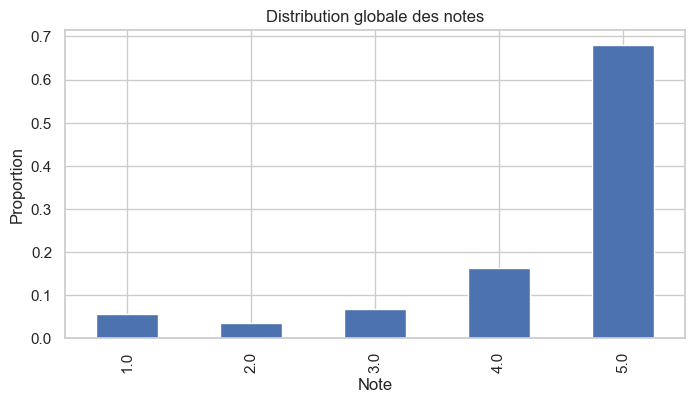

In [6]:
plt.figure(figsize=(8,4))
rating_dist.plot(kind="bar")
plt.title("Distribution globale des notes")
plt.xlabel("Note")
plt.ylabel("Proportion")
plt.show()


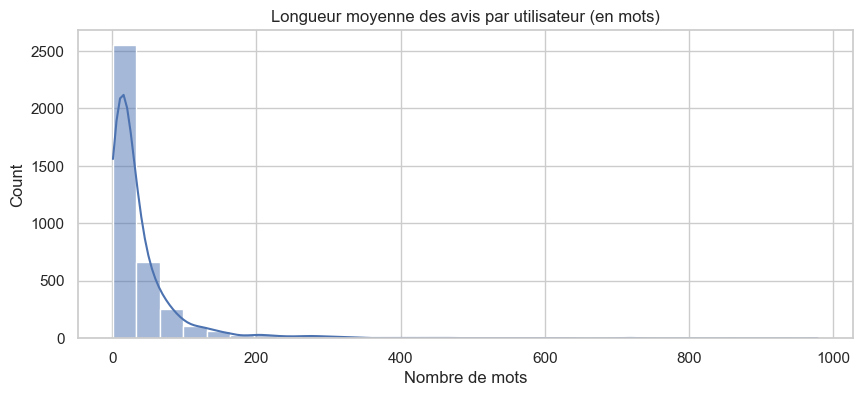

,user_id,avg_review_length
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,17.000000
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,59.000000
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,40.500000
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,9.333333
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,18.666667


In [7]:
df["review_length_words"] = df["text"].astype(str).apply(lambda x: len(x.split()))
user_review_length = df.groupby("user_id")["review_length_words"].mean().reset_index(
    name="avg_review_length"
)

plt.figure(figsize=(10,4))
sns.histplot(user_review_length["avg_review_length"], bins=30, kde=True)
plt.title("Longueur moyenne des avis par utilisateur (en mots)")
plt.xlabel("Nombre de mots")
plt.show()


user_review_length.head()

# avis courts = feedback rapide
# avis longs = utilisateurs impliqués, critiques détaillées


In [9]:
from textblob import TextBlob

def sentiment_score(text):
    return TextBlob(str(text)).sentiment.polarity

df["sentiment"] = df["text"].apply(sentiment_score)


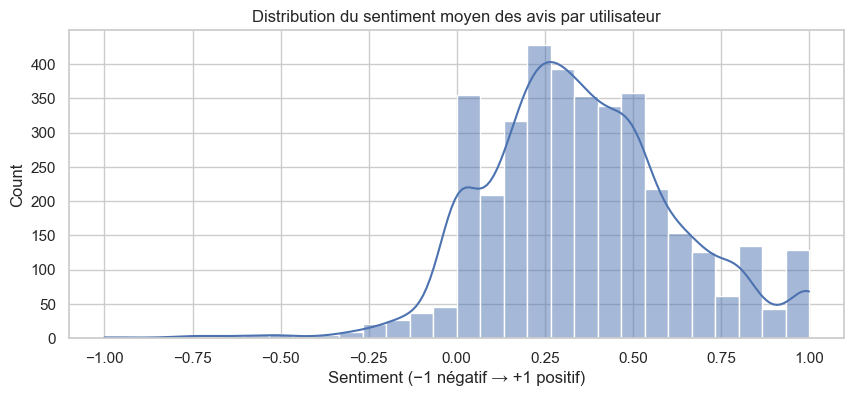

,user_id,avg_sentiment
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,0.416667
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,0.251389
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,0.240655
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,0.439947
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,0.184028


In [10]:
user_sentiment = df.groupby("user_id")["sentiment"].mean().reset_index(
    name="avg_sentiment"
)

plt.figure(figsize=(10,4))
sns.histplot(user_sentiment["avg_sentiment"], bins=30, kde=True)
plt.title("Distribution du sentiment moyen des avis par utilisateur")
plt.xlabel("Sentiment (−1 négatif → +1 positif)")
plt.show()


user_sentiment.head()


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=100
)

tfidf = vectorizer.fit_transform(df["text"].astype(str))


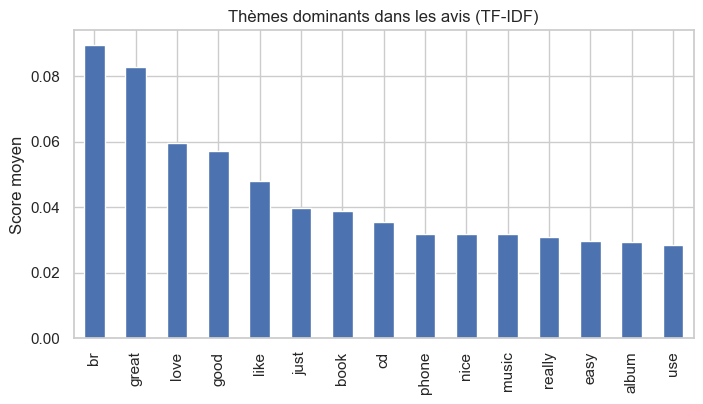

br        0.089431
great     0.082650
love      0.059682
good      0.057210
like      0.047824
just      0.039776
book      0.038798
cd        0.035458
phone     0.031928
nice      0.031700
music     0.031656
really    0.030742
easy      0.029793
album     0.029331
use       0.028341
dtype: float64

In [12]:
feature_names = vectorizer.get_feature_names_out()
scores = tfidf.mean(axis=0).A1

top_words = pd.Series(scores, index=feature_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,4))
top_words.plot(kind="bar")
plt.title("Thèmes dominants dans les avis (TF-IDF)")
plt.ylabel("Score moyen")
plt.show()

top_words


In [13]:
user_style_features = (
    user_rating_stats
    .merge(user_review_length, on="user_id", how="left")
    .merge(user_sentiment, on="user_id", how="left")
)

user_style_features.head()


,user_id,avg_rating,rating_std,nb_reviews,avg_review_length,avg_sentiment
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,5.000000,NaN,1,17.000000,0.416667
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,5.000000,NaN,1,59.000000,0.251389
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,5.000000,0.000000,2,40.500000,0.240655
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,4.555556,1.333333,9,9.333333,0.439947
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,4.333333,0.577350,3,18.666667,0.184028


In [15]:
df.to_csv("../data/processed/user_styles_feature.csv", index=False)
